# Notebook 1 — Data Loading & Labeling

This notebook downloads all CSV files from the HuggingFace dataset `boy177/NADW-network-attacks-dataset`,
attaches ground-truth labels derived from the folder structure, combines everything into one master
DataFrame, runs basic sanity checks, and saves the result to `data/raw_combined.parquet`.

**Label mapping (top-level, 6 classes):**
| Folder | Label |
|---|---|
| benign/ | Benign |
| brute_force/ | Brute_Force |
| exploit/ | Exploit |
| flood/ | Flood |
| malware/ransomware/, malware/spyware/, malware/trojan/ | Malware |
| probe/ | Probe |

In [1]:
import os
import sys
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import snapshot_download

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Project root — all paths are relative to this
PROJECT_ROOT = Path('.')
DATA_DIR     = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

print('Project root:', PROJECT_ROOT.resolve())
print('Data dir    :', DATA_DIR.resolve())

Project root: C:\Users\Manan\Documents\GitHub\NetworkAnomaly-Detection
Data dir    : C:\Users\Manan\Documents\GitHub\NetworkAnomaly-Detection\data


## 1. Download dataset from HuggingFace

We use `snapshot_download` which mirrors the entire repo locally.
Set the environment variable `HF_TOKEN` if the dataset is private.

In [2]:
HF_REPO_ID  = 'boy177/NADW-network-attacks-dataset'
HF_TOKEN    = os.getenv('HF_TOKEN', None)   # None = anonymous (works if dataset is public)
LOCAL_DATA  = DATA_DIR / 'hf_repo'

print(f'Downloading {HF_REPO_ID} ...')

repo_path = snapshot_download(
    repo_id   = HF_REPO_ID,
    repo_type = 'dataset',
    local_dir = str(LOCAL_DATA),
    token     = HF_TOKEN,
    ignore_patterns=['*.parquet', '*.arrow', '.gitattributes', 'README.md'],
)

print(f'Downloaded to: {repo_path}')

Fetching 34 files:   0%|          | 0/34 [00:00<?, ?it/s]

Downloaded to: C:\Users\Manan\Documents\GitHub\NetworkAnomaly-Detection\data\hf_repo


## 2. Define label mapping

Labels are determined by the **top-level folder** each CSV lives in.
The malware folder has sub-folders (ransomware, spyware, trojan) — all map to `Malware`.

In [3]:
# Map top-level folder name → class label
FOLDER_TO_LABEL = {
    'benign':      'Benign',
    'brute_force': 'Brute_Force',
    'exploit':     'Exploit',
    'flood':       'Flood',
    'malware':     'Malware',   # covers ransomware/, spyware/, trojan/ sub-dirs
    'probe':       'Probe',
}

def get_label(csv_path: Path, repo_root: Path) -> str:
    relative = csv_path.relative_to(repo_root)
    parts = relative.parts
    
    # Skip any leading 'dataset' wrapper folder HuggingFace adds
    if parts[0].lower() == 'dataset':
        parts = parts[1:]
    
    top_folder = parts[0].lower().strip()
    return FOLDER_TO_LABEL.get(top_folder, 'Unknown')

## 3. Load all CSVs and attach labels

In [4]:
repo_root = Path(repo_path)

# Find every CSV in the repo (recursive)
all_csvs = sorted(repo_root.rglob('*.csv'))
print(f'Found {len(all_csvs)} CSV files:')
for p in all_csvs:
    print(' ', p.relative_to(repo_root))

Found 34 CSV files:
  dataset\benign\benign-1.csv
  dataset\benign\benign-2.csv
  dataset\benign\benign-3.csv
  dataset\benign\benign-4.csv
  dataset\benign\benign-5.csv
  dataset\brute_force\brute_force.csv
  dataset\brute_force\mysql_brute_force.csv
  dataset\brute_force\redis_brute_force.csv
  dataset\brute_force\SMB_brute_force-2.csv
  dataset\brute_force\SMB_brute_force.csv
  dataset\exploit\brobot.csv
  dataset\exploit\cve-2020.csv
  dataset\exploit\sql-i.csv
  dataset\exploit\tch-ssl.csv
  dataset\flood\http-flood.csv
  dataset\flood\http_slowloris.csv
  dataset\flood\icmp_flood.csv
  dataset\flood\ntp-amplification.csv
  dataset\flood\syn-flood.csv
  dataset\flood\udp_flood.csv
  dataset\malware\ransomware\cerber.csv
  dataset\malware\ransomware\globelmposter.csv
  dataset\malware\ransomware\hidden_tear.csv
  dataset\malware\ransomware\locky.csv
  dataset\malware\ransomware\lord.csv
  dataset\malware\spyware\agent_tesla.csv
  dataset\malware\spyware\form_book.csv
  dataset\malw

In [5]:
def load_csv_safe(path: Path) -> pd.DataFrame:
    """
    Load a CSV with fallback encodings.
    Wireshark exports can sometimes use latin-1 encoding.
    """
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False)
            return df
        except Exception:
            continue
    raise ValueError(f'Could not read {path} with any encoding')


dfs = []
skipped = []

for csv_path in all_csvs:
    label = get_label(csv_path, repo_root)
    if label == 'Unknown':
        print(f'  [SKIP] Unknown label for: {csv_path.relative_to(repo_root)}')
        skipped.append(csv_path)
        continue

    try:
        df = load_csv_safe(csv_path)
        df['label']    = label
        df['src_file'] = str(csv_path.relative_to(repo_root))  # keep provenance
        dfs.append(df)
        # FIXED — convert to string first
        print(f'  [OK]   {str(csv_path.relative_to(repo_root)):55s}  {len(df):>7,} rows  →  {label}')
    except Exception as e:
        print(f'  [ERR]  {csv_path.relative_to(repo_root)} — {e}')
        skipped.append(csv_path)

print(f'\nLoaded {len(dfs)} files | Skipped {len(skipped)} files')

  [OK]   dataset\benign\benign-1.csv                                5,000 rows  →  Benign
  [OK]   dataset\benign\benign-2.csv                                5,000 rows  →  Benign
  [OK]   dataset\benign\benign-3.csv                                5,000 rows  →  Benign
  [OK]   dataset\benign\benign-4.csv                                5,000 rows  →  Benign
  [OK]   dataset\benign\benign-5.csv                                2,084 rows  →  Benign
  [OK]   dataset\brute_force\brute_force.csv                        1,544 rows  →  Brute_Force
  [OK]   dataset\brute_force\mysql_brute_force.csv                  3,048 rows  →  Brute_Force
  [OK]   dataset\brute_force\redis_brute_force.csv                  5,384 rows  →  Brute_Force
  [OK]   dataset\brute_force\SMB_brute_force-2.csv                  7,595 rows  →  Brute_Force
  [OK]   dataset\brute_force\SMB_brute_force.csv                    1,980 rows  →  Brute_Force
  [OK]   dataset\exploit\brobot.csv                                 2,070 r

## 4b. Add your own real-world benign captures ⭐

The HuggingFace benign data is from a lab environment. Your network has QUIC, TLSv1.3,
streaming protocols etc. that the lab data barely contains — causing false positives.

Add paths to any Wireshark CSVs of **known-clean** traffic here and they will be
labelled `Benign` and merged into the training set. The more variety the better.

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Add paths to your own normal traffic Wireshark CSV exports here.
# Leave empty if you have none (model will still work, but may have
# more false positives on traffic types not in the lab benign data).
# ─────────────────────────────────────────────────────────────────────
EXTRA_BENIGN_PATHS = [
    # Path('captures/normalTraffic.csv'),   # <-- your real traffic CSVs go here
    # Path('captures/normalTraffic1.csv'),
   # Path('captures/n.csv'),
]

extra_loaded = 0
for path in EXTRA_BENIGN_PATHS:
    if not path.exists():
        print(f'  [SKIP] {path.name} not found')
        continue
    try:
        df             = load_csv_safe(path)
        df['label']    = 'Benign'
        df['src_file'] = f'extra_benign/{path.name}'
        dfs.append(df)
        extra_loaded  += 1
        print(f'  [OK]  Extra benign: {path.name:40s}  {len(df):>7,} rows')
    except Exception as e:
        print(f'  [ERR] {path.name} — {e}')

if extra_loaded == 0:
    print('No extra benign files loaded.')
    print('Tip: export a ~10min Wireshark capture of clean traffic and add its path above.')
else:
    print(f'\nLoaded {extra_loaded} extra benign file(s) — Benign class now more representative.')


  [OK]  Extra benign: normalTraffic.csv                          26,755 rows
  [OK]  Extra benign: normalTraffic1.csv                          4,313 rows

Loaded 2 extra benign file(s) — Benign class now more representative.


## 4. Combine into master DataFrame

In [7]:
master = pd.concat(dfs, ignore_index=True)

# Standardise column names: strip spaces, lowercase, replace dots/spaces with underscores
master.columns = [
    c.strip().replace('.', '').replace(' ', '_').lower()
    for c in master.columns
]

# Rename 'no_' (from 'No.' column) to 'no'
if 'no_' in master.columns:
    master.rename(columns={'no_': 'no'}, inplace=True)

print('Master DataFrame shape:', master.shape)
print('\nColumns:', master.columns.tolist())
master.head(3)

Master DataFrame shape: (182130, 9)

Columns: ['no', 'time', 'source', 'destination', 'protocol', 'length', 'info', 'label', 'src_file']


,no,time,source,destination,protocol,length,info,label,src_file
0,10001,375.057687,192.168.239.25,239.255.255.250,SSDP,167,M-SEARCH * HTTP/1.1,Benign,dataset\benign\benign-1.csv
1,10002,375.062327,2600:1901:1:b05::,2409:40f4:100b:c1b6:b9fb:3ec3:5675:a236,TLSv1.3,749,"Application Data, Application Data",Benign,dataset\benign\benign-1.csv
2,10003,375.062460,2409:40f4:100b:c1b6:b9fb:3ec3:5675:a236,2600:1901:1:b05::,TCP,86,60888 > 443 [ACK] Seq=1505 Ack=4066 Win=6361...,Benign,dataset\benign\benign-1.csv


## 5. Sanity checks

In [8]:
print('=== Shape ===')
print(f'{master.shape[0]:,} rows  x  {master.shape[1]} columns')

print('\n=== Data types ===')
print(master.dtypes)

print('\n=== Missing values ===')
nulls = master.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'No missing values!')

=== Shape ===
182,130 rows  x  9 columns

=== Data types ===
no               int64
time           float64
source             str
destination        str
protocol           str
length           int64
info               str
label              str
src_file           str
dtype: object

=== Missing values ===
source         1
destination    1
info           1
dtype: int64


In [9]:
print('=== Class distribution ===')
class_dist = master['label'].value_counts()
print(class_dist.to_string())
print(f'\nTotal packets: {len(master):,}')

=== Class distribution ===
label
Exploit        61462
Benign         53152
Flood          29336
Brute_Force    19551
Probe          11629
Malware         7000

Total packets: 182,130


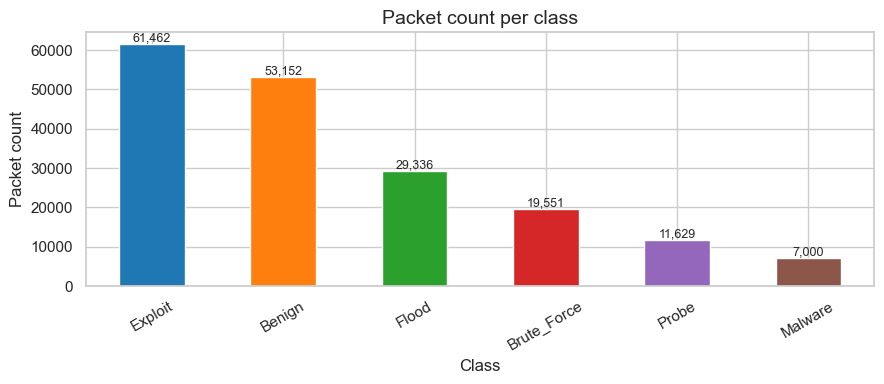

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
class_dist.plot(kind='bar', ax=ax, color=sns.color_palette('tab10', len(class_dist)))
ax.set_title('Packet count per class', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Packet count')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'class_distribution.png', dpi=150)
plt.show()

## 6. Save to Parquet

In [11]:
# Coerce time and length to numeric before saving
master['time']   = pd.to_numeric(master['time'],   errors='coerce')
master['length'] = pd.to_numeric(master['length'], errors='coerce')

out_path = DATA_DIR / 'raw_combined.parquet'
master.to_parquet(out_path, index=False)
print(f'Saved to {out_path}  ({out_path.stat().st_size / 1e6:.1f} MB)')

Saved to data\raw_combined.parquet  (4.1 MB)


## ✅ Notebook 1 complete
**Output:** `data/raw_combined.parquet`  
**Next:** Run `02_eda.ipynb` to explore the data visually.